In [1]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [2]:
import sys
sys.path.append('/content/drive/MyDrive')

In [3]:
from functions import *

# **Bibliotecas e Instalações**

In [4]:
%%capture

!pip install shap
!pip install optuna
!pip install xgboost
!pip install lightgbm

In [5]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '10'  # Qtde de núcleos da CPU

In [6]:
seed = 10 # semente para o random_state
# Básicas
import pandas as pd
import numpy as np
import plotly.express as px

# Modelos
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV


In [7]:
import sklearn
import xgboost

In [8]:
#Carregando dataset no Collab
from google.colab import files


uploaded = files.upload()

Saving data_preProcess2 (1).csv to data_preProcess2 (1).csv


In [10]:
df= pd.read_csv('data_preProcess2 (1).csv', sep = ',', encoding = 'UTF-8',low_memory=False)

In [12]:
df.shape

(56874, 33)

In [13]:
# Valores faltantes
df.isna().sum().sort_values(ascending=False).head(6)

,0
ESCOLARI,0
IDADE,0
IBGE,0
CATEATEND,0
DIAGPREV,0
EC,0


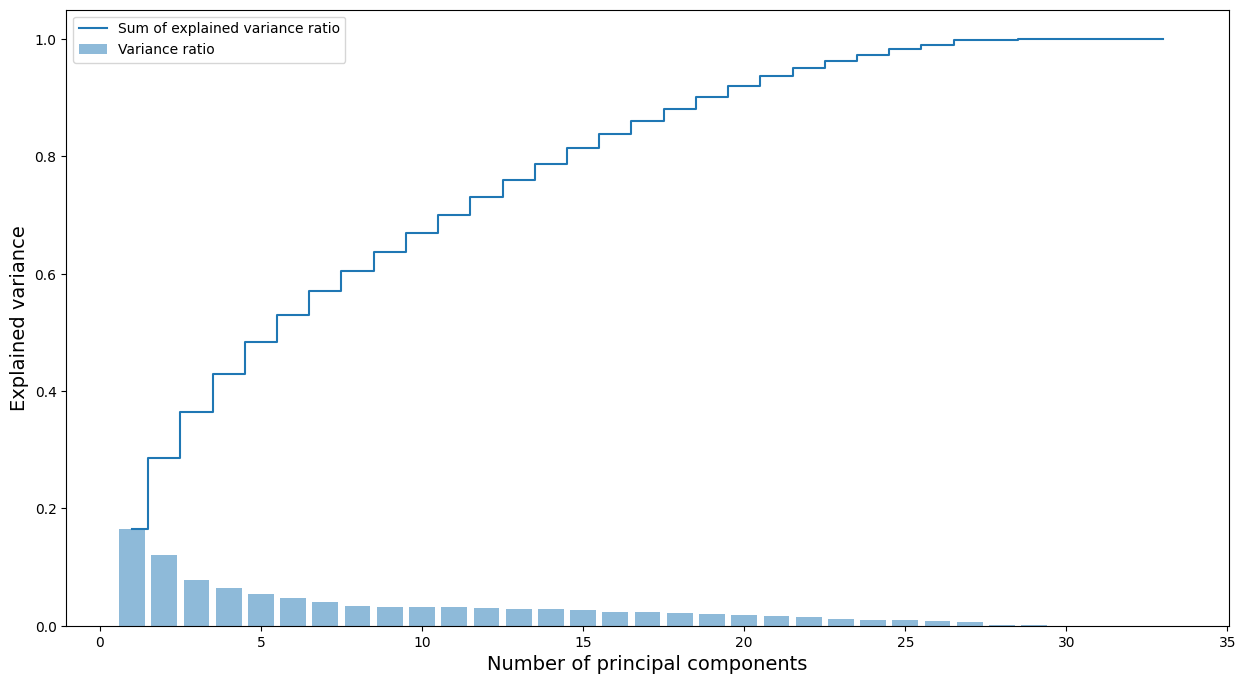

In [14]:
from sklearn.decomposition import PCA

x_tot, _, _, _ = train_preprocessing(df)

pca = PCA()
principalComponents = pca.fit_transform(x_tot)


plt.figure(figsize=(15, 8))

plt.bar(np.linspace(1, x_tot.shape[1], x_tot.shape[1]),
        pca.explained_variance_ratio_, alpha=0.5, align='center',
        label='Variance ratio')
plt.step(np.linspace(1, x_tot.shape[1], x_tot.shape[1]),
         np.cumsum(pca.explained_variance_ratio_), where='mid',
         label='Sum of explained variance ratio')

plt.ylabel('Explained variance', size=14)
plt.xlabel('Number of principal components', size=14)
plt.legend()

plt.show()


In [16]:
from sklearn.cluster import KMeans

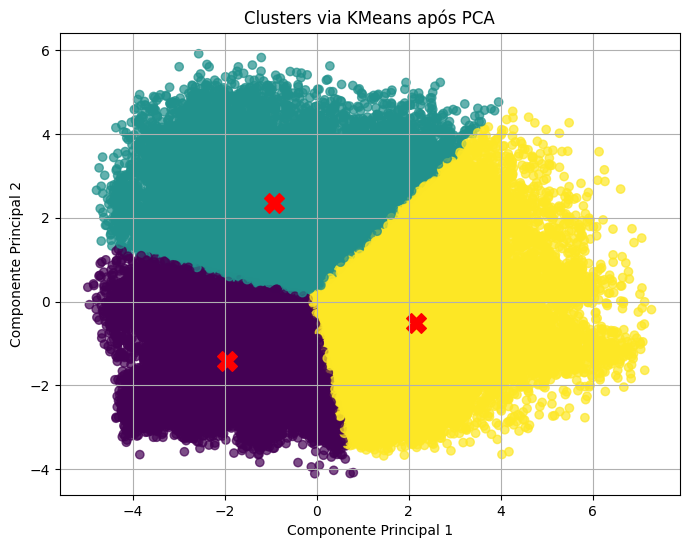

In [24]:
# KMeans com 2 componentes principais (para visualização 2D)
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(x_tot)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca_2d)

# Visualização dos clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X')
plt.title("Clusters via KMeans após PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

In [19]:
from sklearn.metrics import silhouette_score


In [22]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_pca_2d, clusters)
print(f"Silhouette Score: {sil_score:.4f}")


Silhouette Score: 0.3879


In [23]:
print(f"Inertia (KMeans): {kmeans.inertia_:.2f}")

Inertia (KMeans): 200309.53
